# 딥러닝 기초 5일차 실습과제: 전이학습과 최신 트렌드

## 과제 개요
이 과제에서는 **전이학습(Transfer Learning)**을 활용하여 의료 이미지를 분류하고, **Transformer**의 핵심 개념을 이해합니다.

### 사용 데이터셋
- **MedMNIST** (PathMNIST): 대장 조직 병리 이미지 (9 클래스)

### 학습 목표
1. 전이학습의 개념과 장점 이해
2. Feature Extraction vs Fine-tuning 비교
3. 사전학습 모델(ResNet) 활용
4. Transformer의 Self-Attention 개념 이해

### 예상 소요 시간
약 **1시간 30분**

---

## Part 0: 환경 설정

In [2]:
# 필요한 라이브러리 import
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

# 재현성
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# MedMNIST 데이터셋 로드
import medmnist
from medmnist import INFO

# PathMNIST: 대장 조직 병리 이미지
data_flag = 'pathmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

NUM_CLASSES = len(info['label'])
CLASS_NAMES = list(info['label'].values())

print(f"데이터셋: {data_flag}")
print(f"클래스 수: {NUM_CLASSES}")
print(f"클래스: {CLASS_NAMES}")

데이터셋: pathmnist
클래스 수: 9
클래스: ['adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa', 'cancer-associated stroma', 'colorectal adenocarcinoma epithelium']


In [4]:
# 데이터 변환 정의
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def to_rgb(x):
    """1채널 -> 3채널 변환"""
    return x.repeat(3, 1, 1) if x.shape[0] == 1 else x

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(to_rgb),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(to_rgb),
    transforms.Resize((224, 224)),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# 데이터셋 로드
train_dataset = DataClass(split='train', transform=train_transform, download=True)
val_dataset = DataClass(split='val', transform=test_transform, download=True)
test_dataset = DataClass(split='test', transform=test_transform, download=True)

# DataLoader (빠른 실험을 위해 작은 배치)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\nTrain: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 89996, Val: 10004, Test: 7180


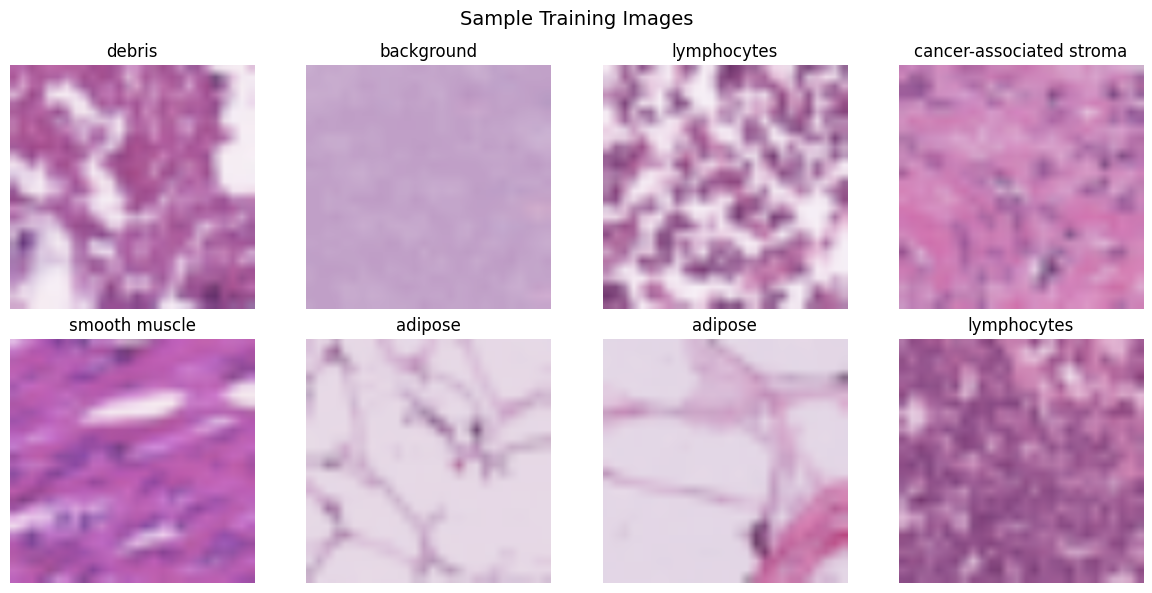

In [5]:
# 샘플 이미지 확인
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i].item()])
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

---

## Part 1: 전이학습 - Feature Extraction

**Feature Extraction**은 사전학습된 모델의 가중치를 **동결**하고, 마지막 분류기만 학습합니다.

- 장점: 빠른 학습, 적은 데이터로도 가능
- 단점: 도메인이 많이 다르면 성능 제한

In [ ]:
# ============================================
# Feature Extraction 모델
# ============================================

def create_feature_extractor(num_classes):
    """
    사전학습된 ResNet18을 Feature Extractor로 사용
    - 모든 레이어 동결
    - 마지막 FC만 학습
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # 모든 파라미터 동결
    for param in model.parameters():
        param.requires_grad = False
    
    # 마지막 FC 레이어만 교체 (이 부분만 학습)
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, num_classes)
    )
    
    return model

# 모델 생성
fe_model = create_feature_extractor(NUM_CLASSES)

# 학습 가능한 파라미터 확인
trainable = sum(p.numel() for p in fe_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in fe_model.parameters())
print(f"Feature Extractor:")
print(f"  학습 가능: {trainable:,} / 전체: {total:,} ({trainable/total*100:.2f}%)")

In [ ]:
# ============================================
# 학습 함수
# ============================================

def train_model(model, train_loader, val_loader, num_epochs=10, lr=0.001, device='cpu'):
    """
    간단한 학습 함수
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    history = {'train_acc': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        # Train
        model.train()
        correct, total = 0, 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = correct / total
        
        # Validate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_acc = correct / total
        
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    
    return model, history

In [ ]:
# Feature Extraction 학습
print("=" * 50)
print("Feature Extraction 학습")
print("=" * 50)

fe_model = create_feature_extractor(NUM_CLASSES)
fe_model, fe_history = train_model(fe_model, train_loader, val_loader, 
                                    num_epochs=5, lr=0.001, device=device)

---

## Part 2: 전이학습 - Fine-tuning

**Fine-tuning**은 사전학습된 모델의 일부 레이어도 함께 학습합니다.

- 장점: 더 높은 성능 가능
- 주의: 더 많은 데이터와 시간 필요, 과적합 위험

In [ ]:
# ============================================
# Fine-tuning 모델
# ============================================

def create_finetuning_model(num_classes):
    """
    ResNet18의 마지막 블록(layer4)과 FC를 함께 학습
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # 모든 파라미터 동결
    for param in model.parameters():
        param.requires_grad = False
    
    # layer4 동결 해제 (Fine-tuning)
    for param in model.layer4.parameters():
        param.requires_grad = True
    
    # FC 레이어 교체
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, num_classes)
    )
    
    return model

# 모델 생성
ft_model = create_finetuning_model(NUM_CLASSES)

trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in ft_model.parameters())
print(f"Fine-tuning:")
print(f"  학습 가능: {trainable:,} / 전체: {total:,} ({trainable/total*100:.2f}%)")

In [ ]:
# Fine-tuning 학습
print("=" * 50)
print("Fine-tuning 학습")
print("=" * 50)

ft_model = create_finetuning_model(NUM_CLASSES)
ft_model, ft_history = train_model(ft_model, train_loader, val_loader,
                                    num_epochs=5, lr=0.0001, device=device)

In [ ]:
# 결과 비교
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(fe_history['val_acc'], label='Feature Extraction', marker='o', color='#8FBC8F')
ax.plot(ft_history['val_acc'], label='Fine-tuning', marker='s', color='#87CEEB')
ax.set_title('Validation Accuracy Comparison')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n최종 Val Accuracy:")
print(f"  Feature Extraction: {fe_history['val_acc'][-1]:.4f}")
print(f"  Fine-tuning: {ft_history['val_acc'][-1]:.4f}")

### [필수] 과제 2-1: 전이학습 비교 분석

1. Feature Extraction과 Fine-tuning의 학습 가능한 파라미터 수 차이는?
feature extraction은 마지막 fc레이어만 학습하기에 파라미터 수가 적음. fine tuning은 layer4와 fc같은 일부 레이어를 함께 학습해 파라미터 수가 더 많음.
2. 어떤 상황에서 Feature Extraction이 더 적합할까요?
   - 답변: feature extraction은 데이터가 적거나 빠르고 안정적인 학습이 필요할 때 적합할것으로 예상됨. fine tuning 은 데이터가 충부닣 많고 새 데이터가 기존 데이터와 다르거나 더 높은 성능을 위해 새 문제에 맞게 조정하고 싶을때 적합할것으로 예상됨.

---

## Part 3: Transformer와 Self-Attention 이해

Transformer는 현대 AI의 핵심 아키텍처입니다. 핵심 개념인 **Self-Attention**을 이해해봅시다.

In [6]:
# ============================================
# Self-Attention 시각화
# ============================================

def simple_self_attention(query, key, value):
    """
    간단한 Self-Attention 구현
    
    Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) * V
    """
    d_k = query.shape[-1]
    
    # 1. Query와 Key의 유사도 계산
    scores = torch.matmul(query, key.transpose(-2, -1)) / np.sqrt(d_k)
    
    # 2. Softmax로 확률화 (Attention Weights)
    attention_weights = torch.softmax(scores, dim=-1)
    
    # 3. Value에 가중치 적용
    output = torch.matmul(attention_weights, value)
    
    return output, attention_weights

# 예시: 문장 "I love AI" (3개 토큰, 4차원 임베딩)
torch.manual_seed(42)
seq_len, d_model = 3, 4
tokens = ['I', 'love', 'AI']

# 임베딩 벡터 (실제로는 학습됨)
embeddings = torch.randn(1, seq_len, d_model)

# Self-Attention: Q=K=V 모두 같은 입력 사용
output, attention = simple_self_attention(embeddings, embeddings, embeddings)

print("입력 임베딩 shape:", embeddings.shape)
print("출력 shape:", output.shape)
print("\nAttention Weights (각 토큰이 다른 토큰에 주는 관심도):")
print(attention[0].numpy().round(3))

입력 임베딩 shape: torch.Size([1, 3, 4])
출력 shape: torch.Size([1, 3, 4])

Attention Weights (각 토큰이 다른 토큰에 주는 관심도):
[[0.332 0.29  0.378]
 [0.034 0.93  0.036]
 [0.307 0.251 0.442]]


/tmp/ipykernel_797/1439680373.py:16: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_797/1439680373.py:16: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_797/1439680373.py:16: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_797/1439680373.py:16: UserWarning: Glyph 53360 (\N{HANGUL SYLLABLE KEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_797/1439680373.py:16: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_797/1439680373.py:16: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 5478

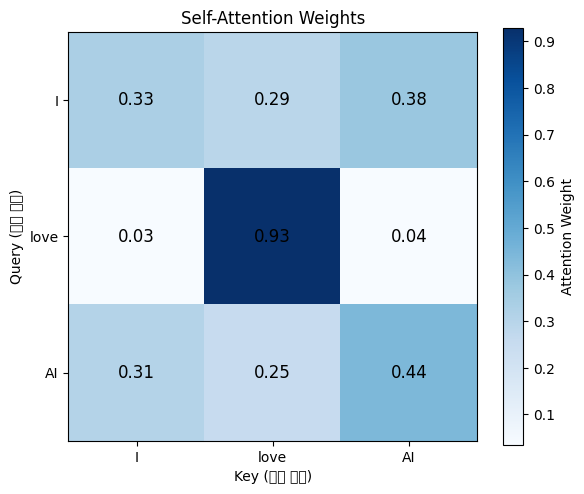


해석: 각 행은 해당 토큰이 다른 토큰들에 얼마나 '관심'을 주는지를 보여줍니다.


In [7]:
# Attention 시각화
plt.figure(figsize=(6, 5))
plt.imshow(attention[0].numpy(), cmap='Blues')
plt.colorbar(label='Attention Weight')
plt.xticks(range(seq_len), tokens)
plt.yticks(range(seq_len), tokens)
plt.xlabel('Key (다른 토큰)')
plt.ylabel('Query (현재 토큰)')
plt.title('Self-Attention Weights')

# 값 표시
for i in range(seq_len):
    for j in range(seq_len):
        plt.text(j, i, f'{attention[0, i, j]:.2f}', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

print("\n해석: 각 행은 해당 토큰이 다른 토큰들에 얼마나 '관심'을 주는지를 보여줍니다.")

### Transformer 핵심 개념 정리

| 개념 | 설명 |
|------|------|
| **Self-Attention** | 문장 내 모든 단어가 서로를 참조 |
| **Multi-Head** | 여러 관점에서 Attention 계산 |
| **Positional Encoding** | 순서 정보 추가 (RNN 없이!) |
| **BERT** | 양방향 이해 (빈칸 채우기 학습) |
| **GPT** | 단방향 생성 (다음 단어 예측) |

### [필수] 과제 3-1: Transformer 이해도 점검

1. Self-Attention이 RNN보다 좋은 점은 무엇인가요?
   - 답변: 멀리 떨어진 던어끼리도 직접 연결해서 관계를 학습할 수 있기에 긴 문맥을 이해하는데 더 유리함

2. BERT와 GPT의 가장 큰 차이점은?
   - 답변: bert는 양방향으로 이해하는 모델이고 gpt는 왼쪽에서 오른쪽으로 다음 단어를 예측하는 단방향 모델이다.

---

## Part 4: [도전] HuggingFace로 감성 분석

실제 사전학습된 Transformer 모델을 사용해봅시다.

In [9]:
# [도전 과제] HuggingFace Transformers 사용해보기
# 아래 코드를 실행하고 다른 문장으로도 테스트해보세요!

try:
    from transformers import pipeline
    
    # 감성 분석 파이프라인
    sentiment = pipeline('sentiment-analysis')
    
    # 테스트 문장들
    texts = [
        "I love learning deep learning!",
        "This is really difficult and frustrating.",
        "The medical AI can save many lives."
    ]
    
    print("감성 분석 결과:")
    print("=" * 50)
    for text in texts:
        result = sentiment(text)[0]
        print(f"입력: {text}")
        print(f"결과: {result['label']} (신뢰도: {result['score']:.4f})")
        print()
        
except ImportError:
    print("transformers 라이브러리가 필요합니다.")
    print("설치: !pip install transformers")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

감성 분석 결과:
입력: I love learning deep learning!
결과: POSITIVE (신뢰도: 0.9998)

입력: This is really difficult and frustrating.
결과: NEGATIVE (신뢰도: 0.9993)

입력: The medical AI can save many lives.
결과: POSITIVE (신뢰도: 0.9186)



---

## 5일차 학습 정리 체크리스트

- [ ] **전이학습**: 사전학습된 모델을 새 작업에 활용
- [ ] **Feature Extraction**: 가중치 동결, 분류기만 학습 (빠름)
- [ ] **Fine-tuning**: 일부 레이어도 함께 학습 (고성능)
- [ ] **Self-Attention**: 문장 내 모든 위치가 서로 참조
- [ ] **Transformer**: Attention만으로 구성, 병렬 처리 가능
- [ ] **BERT/GPT**: 대표적인 사전학습 언어 모델

---

## 수고하셨습니다! 🎉

5일간의 딥러닝 기초 과정을 모두 완료했습니다!

### 제출 전 체크리스트
- [ ] 과제 2-1 (전이학습 비교) 답변 작성
- [ ] 과제 3-1 (Transformer 이해) 답변 작성
- [ ] [선택] 도전 과제 (HuggingFace 실행)